In [88]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

In [89]:
words = open('names.txt', 'r').read().splitlines()# read in all the words
print(words[:8])           # Show the first eight words

# Build a vocabulary of characters and map them to integers
chars = sorted(list(set(''.join(words))))# set(): Throwing out letter duplicates
stoi = {s:i+1 for i,s in enumerate(chars)}# Make tuples of type (char, counter)
stoi['.'] = 0 # Add this special symbol's entry explicitly
itos = {i:s for s,i in stoi.items()} # Switch order of (char, counter) to (counter, char)

#print total number of words and characters in the vocabulary
print(f'{len(words)} words, {len(chars)} unique characters')
block_size = 8
batch_size = 32
n_embd = 10 # dimensionality of the character embedding vectors
n_hidden = 68 # number of neurons in the hidden layer of the MLP
n_out = len(stoi)
vocab_size = n_out
max_steps = 200000 # how many batches to train on
print(f'{n_out} output classes, (unique characters) (including padding character)')
#print out hyperparameters
print(f'block_size: {block_size}, batch_size: {batch_size}, n_embd: {n_embd}, n_hidden: {n_hidden}')
print(f'max_steps: {max_steps}')
print(itos)
print(stoi)
print(vocab_size)

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
32033 words, 26 unique characters
27 output classes, (unique characters) (including padding character)
block_size: 8, batch_size: 32, n_embd: 10, n_hidden: 68
max_steps: 200000
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
27


In [90]:
def build_dataset(words):
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print('X:', X.shape, '\tY:', Y.shape)
    return X,Y

# Randomize the dataset (with reproducibility)
random.seed(42)          # for reproducibility
random.shuffle(words)    # words is just the bare list of all names, from wayyy above

n1 = int(0.8*len(words)) # index at 80% of all words (rounded for integer indexing)
n2 = int(0.9*len(words)) # index at 90% of all words (rounded for integer indexing)

# Dividing the dataset into train, dev and test splits
print('Training Set:')
Xtr, Ytr = build_dataset(words[:n1])     # The first 80% of all words
print('Validation Set:')
Xdev, Ydev = build_dataset(words[n1:n2]) # The 10% from 80% to 90% of all words
print('Test Set:')
Xte, Yte = build_dataset(words[n2:])     # The 10% from 90% to 100% of all words

Training Set:
X: torch.Size([182625, 8]) 	Y: torch.Size([182625])
Validation Set:
X: torch.Size([22655, 8]) 	Y: torch.Size([22655])
Test Set:
X: torch.Size([22866, 8]) 	Y: torch.Size([22866])


In [91]:
# Show the dataset's layout -> Three inputs, one expected output (given the three, expect the fourth)
# We have (as seen above) 182625 of these 'three, give fourth' sets of characters
for x, y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [ ]:
# Near copy/paste of the layers developed in Makemore 3
# -----------------------------------------------------

# Mimicks torch.nn.linear
class Linear:
  
  # fan_in: Number of input dimensions
  # fan_out: Number of output dimensions
  # bias: Whether to add a bias term or not
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5  # Kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  # Performs a forward pass if called (syntax: l = Linear(x))
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  # Returns a list of the parameters (syntax: l.parameters())
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


# Mimicks torch.nn.batchnorm1d
class BatchNorm1d_Torch:
  
  # dim represents the dimension along which the normalization is applied
  # PyTorch's BatchNorm is also performed along just one dimension
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps           # Small constant for numerical stability
    self.momentum = momentum # Running mean/variance momentum
    # Batchnorm1d behaves differently during training and production
    self.training = True
    # Parameters (trained with backprop)
    self.gamma = torch.ones(dim) # Scaling
    self.beta = torch.zeros(dim) # Shifting
    # Buffers (trained with a running 'momentum update' outside backprop)
    self.running_mean = torch.zeros(dim) # Batchnorm mean
    self.running_var = torch.ones(dim)   # Batchnorm variance

# NOT ANYMORE Mimicking torch.nn.batchnorm1d
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    # Batchnorm1d behaves differently during training and production
    self.training = True
    # Parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # Buffers (trained with a running 'momentum update' outside backprop)
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # Calculate the forward pass
    if self.training:
      # THIS IS THE NEW PART! IT BREAKS WITH PYTORCH LINGUA
      # Addressing the 'wrong mean' problem from above
      if x.ndim == 2:
        dim = 0 # average just over the batch dimension
      elif x.ndim == 3:
        dim = (0,1) # average over both the batch and character dimensions
      xmean = x.mean(dim, keepdim=True) # Batchnorm mean
      xvar = x.var(dim, keepdim=True) # Batchnorm variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # Normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # Update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]    
  
  # Forward pass (syntax: bn = BatchNorm1d(x), where x is a batch of inputs)
  def __call__(self, x):
    # If we're in training mode, calculate the batch mean and variance (for active normalization)
    # Otherwise, use the running mean and variance (for passive normalization)
    if self.training:
      xmean = x.mean(0, keepdim=True) # Batch mean
      xvar  = x.var(0, keepdim=True)  # Batch variance
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var  = (1 - self.momentum) * self.running_var + self.momentum * xvar
    else:
      xmean = self.running_mean # Use pre-determined running mean/variance
      xvar  = self.running_var  # (pre-determined = calculated during training)
    
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # Normalize to unit variance
    self.out = self.gamma * xhat + self.beta # Scale and shift (gamma and beta are learned)
    return self.out
  
  # Returns the list of this layer's parameters (syntax: bn.parameters())
  def parameters(self):
    return [self.gamma, self.beta]


# Mimicks torch.nn.tanh
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []

# Does the indexing operation
# Mimicks torch.nn.embedding
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    # What was previously C (lookup table) is now the weight in this layer
    self.weight = torch.randn((num_embeddings, embedding_dim)) # Behaves just like C did

  # This is the forward pass (syntax: embedding(IX))   
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  # Returns list of all layer parameters (syntax: embedding.parameters())
  def parameters(self):
    return [self.weight]    

# Does the vector flattening
class Flatten:
  # This is the forward pass (syntax: flatten(x))
  # x is a tensor of shape (N, block_size, n_embd), where N is the batch size, n_embd is the embedding dimension
  def __call__(self, x):
    # Concatenate the vectors, 
    # x.shape[0] is the batch size, 
    # -1 means "infer the rest" (in this case, block_size * n_embd)
    self.out = x.view(x.shape[0], -1)
    return self.out
  
  # Returns list of all layer parameters (none in this case, syntax: flatten.parameters())
  def parameters(self):
    return []    

# NOT ANYMORE mimicking torch.nn.flatten
class FlattenConsecutive:
    
  def __init__(self, n):  # n is the number of consecutive elements to be concatenated
    self.n = n
    
  def __call__(self, x):
    B, T, C = x.shape # 4, 8, 10 in example before
    x = x.view(B, T//self.n, C*self.n) # Flattening in groups, now 4, 4, 20 for n=2 characters
    if x.shape[1] == 1:
        x = x.squeeze(1) # Takes out the dimension 1, as it only has value 1 (irrelevant)
    self.out = x
    return self.out
  
  def parameters(self):
    return []    

# Mimicks torch.nn.Sequential
class Sequential:
  
  def __init__(self, layers):
    # Psst, this is basically the same list structure as before
    self.layers = layers
  
  # Simply pass input x through every layer in self.layers
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  # Get parameters of all layers, stretch them out into one list
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [93]:
model = Sequential([
    Embedding(vocab_size, n_embd), # NEW: previously C = torch.randn((vocab_size, n_embd))
    # The new layer at work now (block_size was 8 before)
    FlattenConsecutive(2), # (B, 8, n_embd) -> (B, 4, 2*n_embd)
    Linear(n_embd * 2, n_hidden, bias=False), # same weights applied to all 4 groups
    BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),    
    Linear(n_hidden, vocab_size), # output layer, no activation (we'll apply softmax later)
])

# the mathematically identical convolution:
    # conv = nn.Conv1d(in_channels=n_embd, out_channels=n_hidden, kernel_size=2, stride=2)
# kernel_size=2  -> the "pair" (2 characters per window)
# stride=2       -> non-overlapping pairs (the 8→4→2→1 squashing tree)
# in_channels    -> the embedding dims (your 2)
# out_channels   -> n_hidden (the H per box)
# weight sharing -> the defining property of conv: one kernel, all positions

# the paper's WaveNet uses stride=1 with dilation doubling per layer (1, 2, 4, 8 — overlapping windows reaching further back), 
# while makemore uses stride=2 with no dilation (non-overlapping pairs — the clean tree you drew the tree for). 
# Both give the "2 neurons squash into 1, receptive field doubles per level" picture; the wiring detail differs.

# Parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # Making last layer less confident (in beginning)

# Print the number of parameters in the model
parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # Number of parameters in total
for p in parameters:
  p.requires_grad = True

22397


In [94]:
# This is neat, it shows the shape of the output of each layer
for layer in model.layers:
    if hasattr(layer, 'out'):
        print(layer.__class__.__name__, ':', tuple(layer.out.shape))
    else:
        if hasattr(layer, 'weight'):
            print(layer.__class__.__name__, ':', tuple(layer.weight.shape))
        else:
            print(layer.__class__.__name__, ':', 'No output or weight attribute')

Embedding : (27, 10)
FlattenConsecutive : No output or weight attribute
Linear : (20, 68)
BatchNorm1d : No output or weight attribute
Tanh : No output or weight attribute
FlattenConsecutive : No output or weight attribute
Linear : (136, 68)
BatchNorm1d : No output or weight attribute
Tanh : No output or weight attribute
FlattenConsecutive : No output or weight attribute
Linear : (136, 68)
BatchNorm1d : No output or weight attribute
Tanh : No output or weight attribute
Linear : (68, 27)


In [96]:
lossi = []

for i in range(max_steps):
    
    # Mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix] # X,Y's of this batch
    
    # Forward-Pass
    logits = model(Xb) # our new Sequential container in action
    loss = F.cross_entropy(logits, Yb)  # Loss function
    
    # Backward-Pass
    for p in parameters:
        # Making sure that prior iteration's gradients are gone
        p.grad = None
    loss.backward() # This calculates the current (new) gradients
    
    # Update (mini-batch SGD with no fluff)
    lr = 0.1 if i < 150000 else 0.01 # Learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # Printing track stats every once in a while
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    
    # Adding current loss value to historic losses set (for later display)
    lossi.append(loss.log10().item())

      0/ 200000: 3.2962
  10000/ 200000: 2.0123
  20000/ 200000: 2.5564
  30000/ 200000: 2.1531
  40000/ 200000: 2.2965
  50000/ 200000: 2.1629
  60000/ 200000: 2.1780
  70000/ 200000: 1.9458
  80000/ 200000: 1.9770
  90000/ 200000: 2.0720
 100000/ 200000: 1.8287
 110000/ 200000: 2.4391
 120000/ 200000: 1.9966
 130000/ 200000: 2.4362
 140000/ 200000: 2.2642
 150000/ 200000: 2.5514
 160000/ 200000: 2.2386
 170000/ 200000: 2.0162
 180000/ 200000: 1.6799
 190000/ 200000: 1.7585


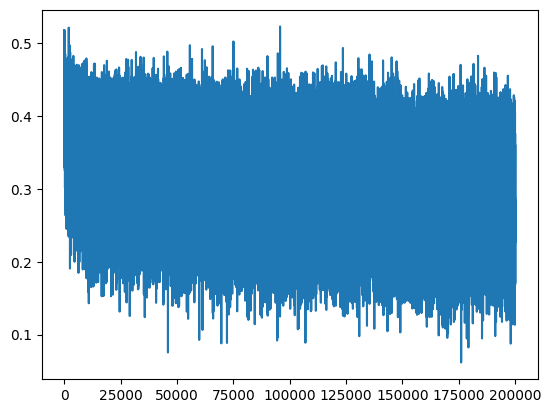

In [97]:
plt.plot(lossi);

In [98]:
#Let's also determine the training and validation losses at this point:

# Put layers into eval mode (needed for batchnorm ESPECIALLY)
# (Accessing Sequential's layers directly like this is bad, we'll fix this later)
for layer in model.layers:
    layer.training = False

# See Makemore #2.
# We did this before but it's refactored here for convenience:
@torch.no_grad() # Decorator, disables gradient tracking (no "book-keeping" on torch's side for this function)
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]   # That's a switch!
    
    logits = model(x) # This got simplified
    
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.938215970993042
val 2.0239923000335693


In [99]:
# Sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # Forward pass though the neural net
      x = torch.tensor([context]) # batch input later gets embedded into vectors
      logits = model(x) # This got simplified
      
      probs = F.softmax(logits, dim=1)

      # Sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # Shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # As soon as we sample the special '.' token, break
      if ix == 0:
        break
    
    # Decode and print the generated words (Inferences)
    print(''.join(itos[i] for i in out))

aiin.
hari.
suharia.
aayvo.
stana.
bushmine.
ojse.
zevaya.
mechem.
esmia.
remd.
kirabella.
macay.
aiden.
aalkin.
anahayi.
gabrion.
yazaeh.
reiley.
laliyah.


torch.Size([200, 1000])
torch.Size([200])


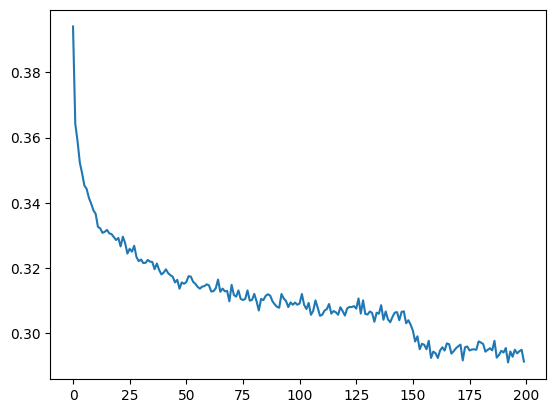

In [100]:
#Addressing the noisy loss graph
print(torch.tensor(lossi).view(-1, 1000).shape)         # Each row has 1000 consecutive losses
print(torch.tensor(lossi).view(-1, 1000).mean(1).shape) # Row-wise mean -> 200 means for 200 rows
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1));   # Mean on every Row -> 200 means as array

# This is a very simple approach to make the loss graph more readable. Elegant nonetheless.
# For example, we can now clearly see where the learning rate was decreased, 
# and that this indeed resulted in a finer approach of the "perfect" local minimum i.e. less error overall.

In [101]:
[model.layers[0].weight.shape, 
model.layers[1].out.shape, 
model.layers[2].weight.shape, 
model.layers[3].out.shape, 
model.layers[4].out.shape, 
model.layers[5].out.shape]

[torch.Size([27, 10]),
 torch.Size([1, 4, 20]),
 torch.Size([20, 68]),
 torch.Size([1, 4, 68]),
 torch.Size([1, 4, 68]),
 torch.Size([1, 2, 136])]

In [102]:
model.layers

In [103]:
[[model.layers[0].out.shape, 0], # Embedding layer has no weights
 [model.layers[1].out.shape, 0], # Flatten layer has no weights
 [model.layers[2].out.shape, model.layers[2].weight.shape], # Linear layer has weights
 [model.layers[3].out.shape, 0], # BatchNorm layer has no weights
 [model.layers[4].out.shape, 0], # Tanh layer has no weights
 [model.layers[5].out.shape, 0], # Flatten layer has no weights
 [model.layers[6].out.shape, model.layers[6].weight.shape],# Linear layer has weights
 [model.layers[7].out.shape, 0], # BatchNorm layer has no weights
 [model.layers[8].out.shape, 0], # Tanh layer has no weights
 [model.layers[9].out.shape, 0], # Flatten layer has no weights
 [model.layers[10].out.shape, model.layers[10].weight.shape],# Linear layer has weights
 [model.layers[11].out.shape, 0], # BatchNorm layer has no weights
 [model.layers[12].out.shape, 0], # Tanh layer has no weights
 [model.layers[13].out.shape, model.layers[13].weight.shape]] # Linear layer has weights

[[torch.Size([1, 8, 10]), 0],
 [torch.Size([1, 4, 20]), 0],
 [torch.Size([1, 4, 68]), torch.Size([20, 68])],
 [torch.Size([1, 4, 68]), 0],
 [torch.Size([1, 4, 68]), 0],
 [torch.Size([1, 2, 136]), 0],
 [torch.Size([1, 2, 68]), torch.Size([136, 68])],
 [torch.Size([1, 2, 68]), 0],
 [torch.Size([1, 2, 68]), 0],
 [torch.Size([1, 136]), 0],
 [torch.Size([1, 68]), torch.Size([136, 68])],
 [torch.Size([1, 68]), 0],
 [torch.Size([1, 68]), 0],
 [torch.Size([1, 27]), torch.Size([68, 27])]]